In [1]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [2]:
def set_mpl_params(dpi=150, figsize=(9, 6), grid=True, font_size=16, font_family='serif'):
    """
    Function to set matplotlib parameters for plotting.

    Parameters:
    dpi (int): Dots per inch for the plot. Default is 300.
    figsize (tuple): Figure size for the plot. Default is (18, 12).
    grid (bool): Whether to show grid in the plot. Default is True.
    font_size (int): Font size for the text in the plot. Default is 16.
    font_family (str): Font family for the text in the plot. Default is 'serif'.

    Returns:
    None

    This function updates the default parameters in matplotlib's rcParams dictionary to 
    customize the look and feel of matplotlib plots. The parameters include dots per inch (dpi) 
    for plot resolution, figure size, grid visibility, font size, and font family.
    """
    import matplotlib as mpl
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family
set_mpl_params()

In [3]:
# 1. Data Generation
np.random.seed(42)
class0 = np.random.normal(loc=[0,0], scale=0.8, size=(100,2))
class1 = np.random.normal(loc=[1,1], scale=0.8, size=(100,2))
X = np.vstack([class0, class1])
y = np.hstack([np.zeros(100), np.ones(100)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

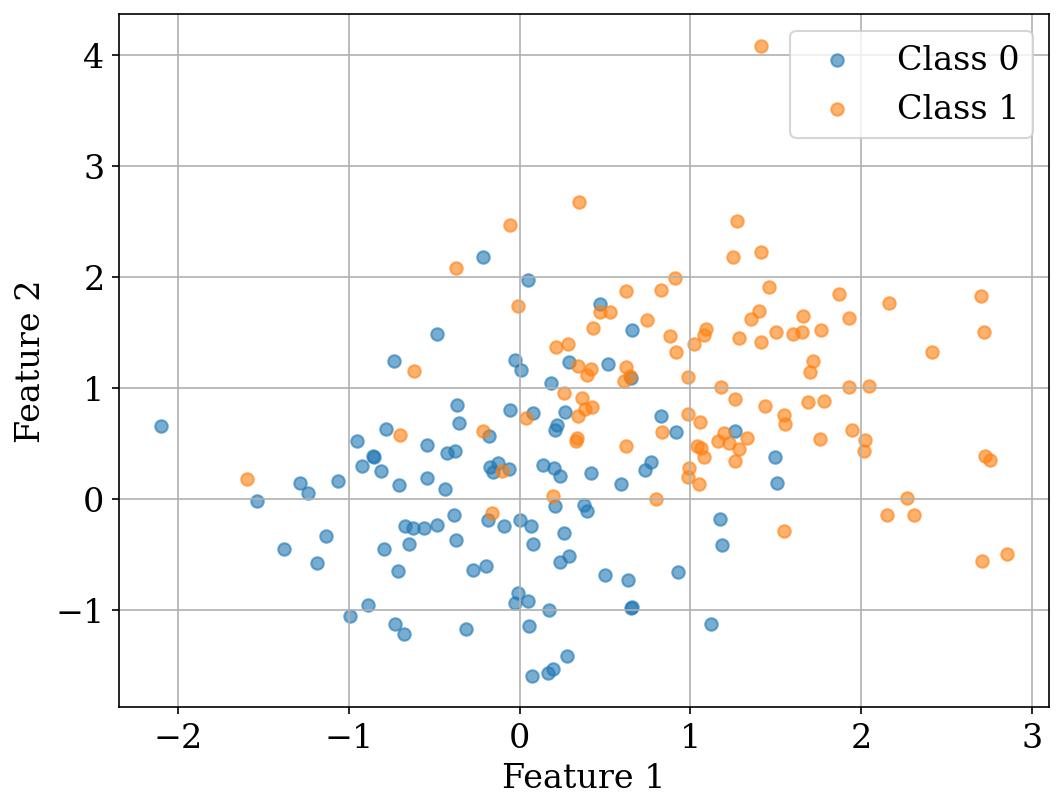

(<matplotlib.legend.Legend at 0x70b2a2710580>, None)

In [4]:
# 2. Visualization
plt.figure(figsize=(8,6))
plt.scatter(class0[:,0], class0[:,1], label='Class 0', alpha=0.6)
plt.scatter(class1[:,0], class1[:,1], label='Class 1', alpha=0.6)
plt.xlabel('Feature 1'), plt.ylabel('Feature 2')
plt.legend(), plt.show()

In [5]:
# 3. Perceptron Implementation
class Perceptron:
    def __init__(self, lr=0.01, n_epochs=50):
        self.lr = lr
        self.n_epochs = n_epochs
        
    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1] + 1)  # +1 for bias
        for _ in range(self.n_epochs):
            for xi, target in zip(X, y):
                xi = np.insert(xi, 0, 1)  # Add bias term
                prediction = self.predict(xi[1:])
                update = self.lr * (target - prediction)
                self.weights += update * xi
                
    def predict(self, X):
        return np.where(np.dot(X, self.weights[1:]) + self.weights[0] >= 0, 1, 0)

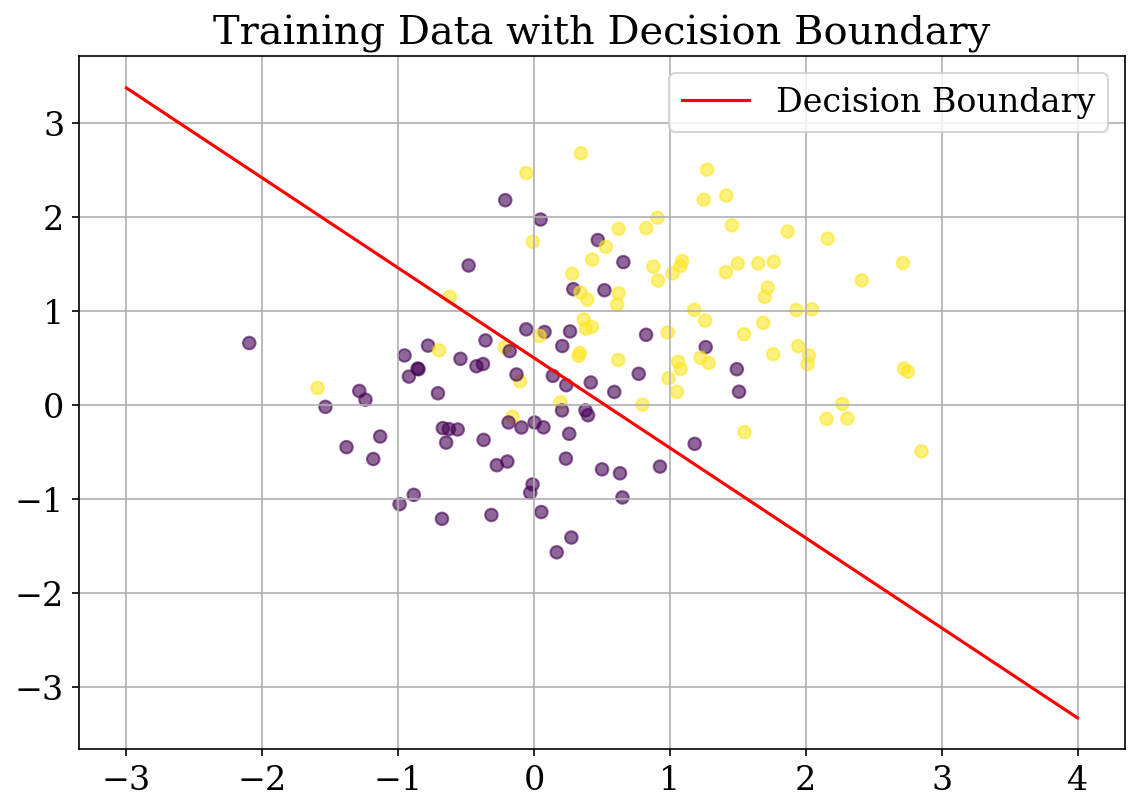

(<matplotlib.legend.Legend at 0x70b3801a5660>, None)

In [6]:
model = Perceptron(lr=0.01)
model.fit(X_train, y_train)

# Plot decision boundary
x1 = np.linspace(-3, 4, 100)
x2 = -(model.weights[0] + model.weights[1]*x1)/model.weights[2]
plt.plot(x1, x2, c='red', label='Decision Boundary')
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, alpha=0.6)
plt.title('Training Data with Decision Boundary')
plt.legend(), plt.show()

Test Accuracy: 0.85


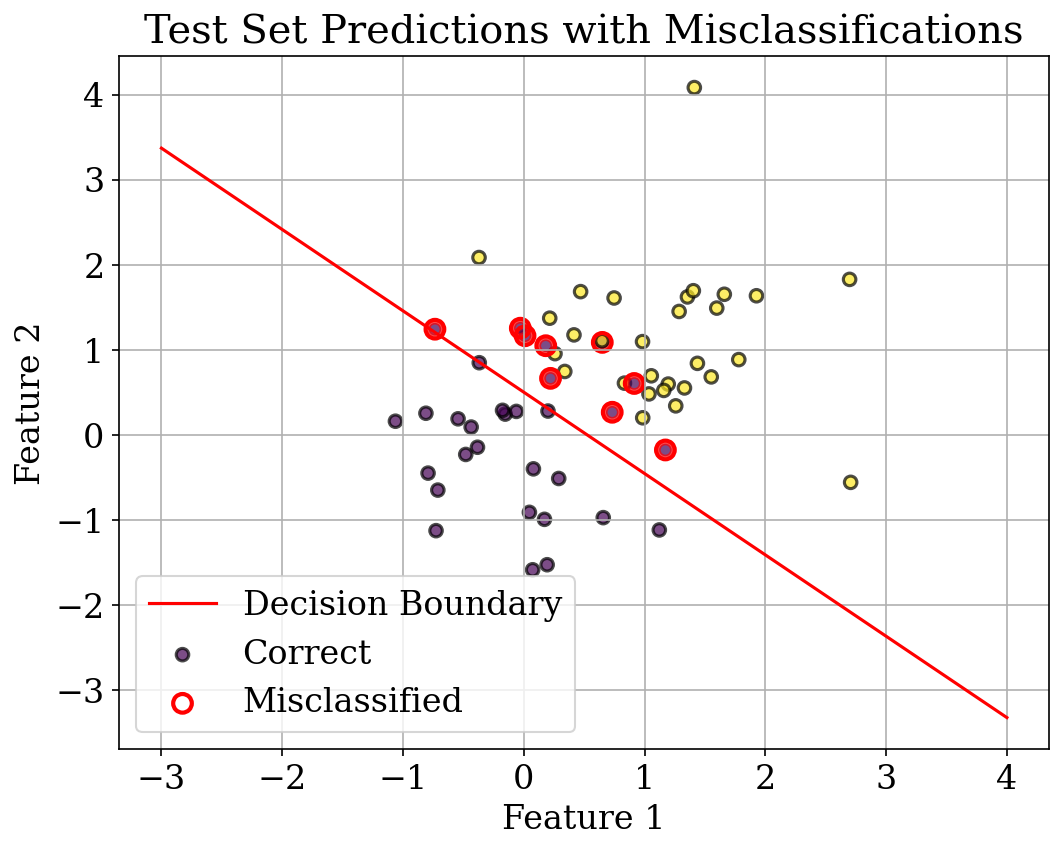

In [7]:
# Test accuracy
test_preds = model.predict(X_test)
accuracy = np.mean(test_preds == y_test)
print(f"Test Accuracy: {accuracy:.2f}")

plt.figure(figsize=(8,6))
x1 = np.linspace(-3, 4, 100)
x2 = -(model.weights[0] + model.weights[1]*x1)/model.weights[2]
plt.plot(x1, x2, c='red', label='Decision Boundary')

# Create edge colors for misclassified points
misclassified = test_preds != y_test
edge_colors = ['red' if mc else 'none' for mc in misclassified]

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, 
            edgecolors=edge_colors, linewidths=1.5, 
            alpha=0.7, label='Correct')
plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1], 
            facecolor='none', edgecolor='red', linewidths=2, 
            s=80, label='Misclassified')

plt.xlabel('Feature 1'), plt.ylabel('Feature 2')
plt.title('Test Set Predictions with Misclassifications')
plt.legend()
plt.show()



In [8]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate 1000 samples with 30% noise
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


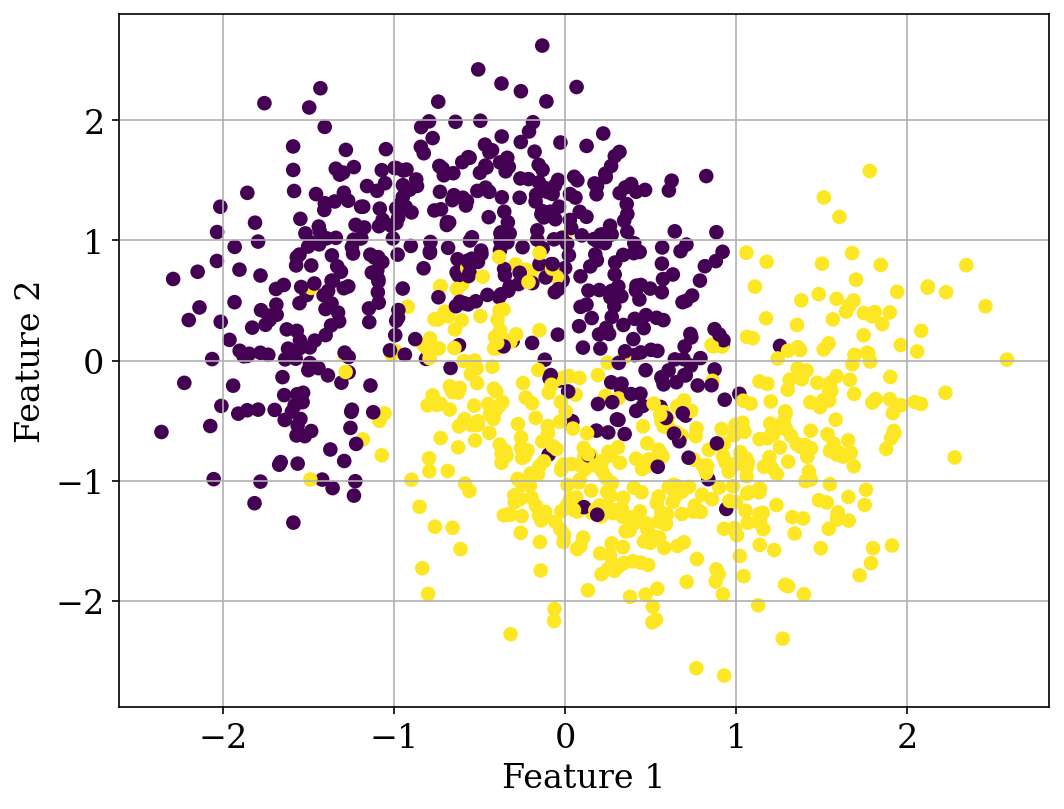

In [9]:
# 2. Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel('Feature 1'), plt.ylabel('Feature 2')
plt.show()

In [10]:
# Visualization function
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:,0], X[:,1], c=y, s=20, edgecolor='k')
    plt.title(title)


Train: 0.85, Test: 0.85


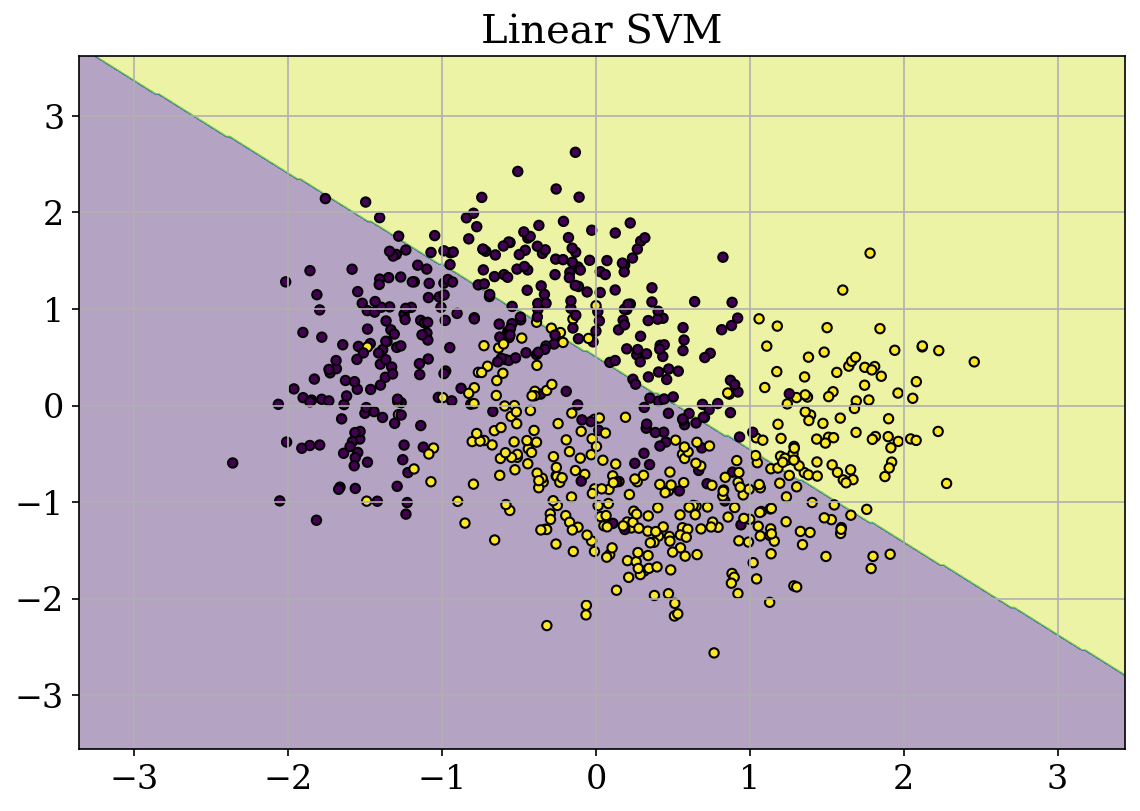

In [11]:
# Task 1: Linear SVM
linearSVM = SVC(kernel='linear', C=0.1)

linearSVM.fit(X_train, y_train)
plt.figure()
plot_decision_boundary(X_train, y_train, model, f'Linear SVM')
print(f"Train: {linearSVM.score(X_train, y_train):.2f}, Test: {linearSVM.score(X_test, y_test):.2f}")

RBF SVM - Train: 0.91, Test: 0.90
C=0.1: Train 0.88, Test 0.90
C=1: Train 0.91, Test 0.90
C=100: Train 0.92, Test 0.92


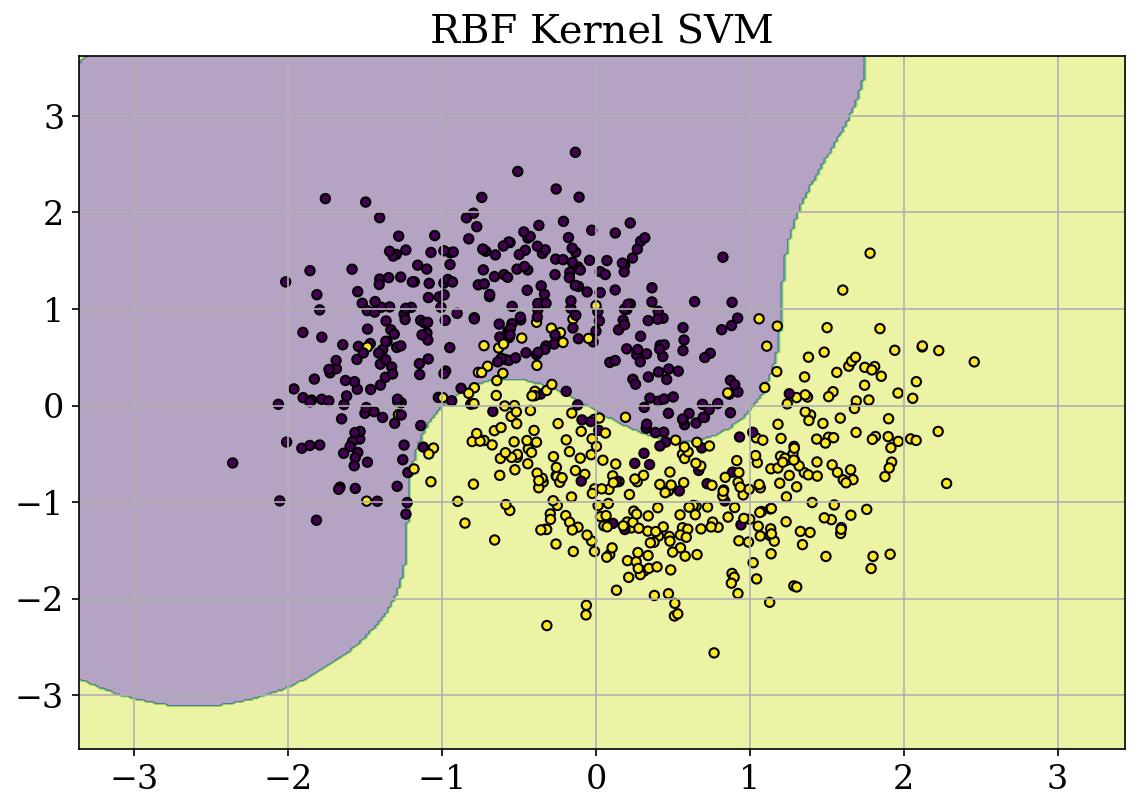

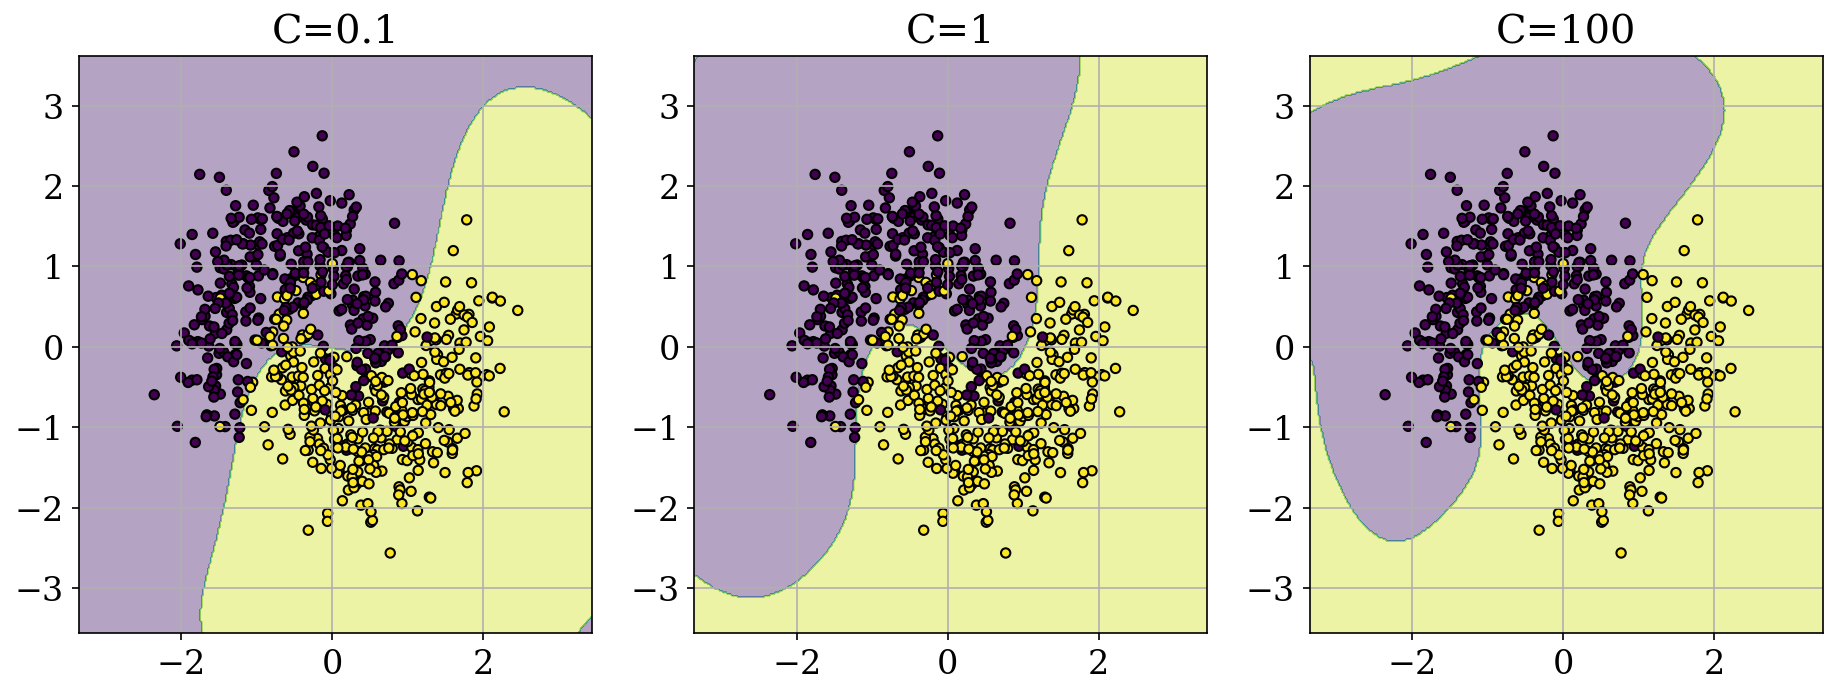

In [12]:
# Task 2: Non-Linear SVM
rbf_model = SVC(kernel='rbf', C=1, gamma='scale')
rbf_model.fit(X_train, y_train)
plot_decision_boundary(X_train, y_train, rbf_model, 'RBF Kernel SVM')
print(f"RBF SVM - Train: {rbf_model.score(X_train, y_train):.2f}, Test: {rbf_model.score(X_test, y_test):.2f}")

# Task 3: C Parameter Analysis
C_values = [0.1, 1, 100]
plt.figure(figsize=(15,5))
for i, C in enumerate(C_values):
    model = SVC(kernel='rbf', C=C, gamma='scale')
    model.fit(X_train, y_train)
    plt.subplot(1, 3, i+1)
    plot_decision_boundary(X_train, y_train, model, f'C={C}')
    print(f"C={C}: Train {model.score(X_train, y_train):.2f}, Test {model.score(X_test, y_test):.2f}")

Overfit model - Train: 0.97, Test: 0.87


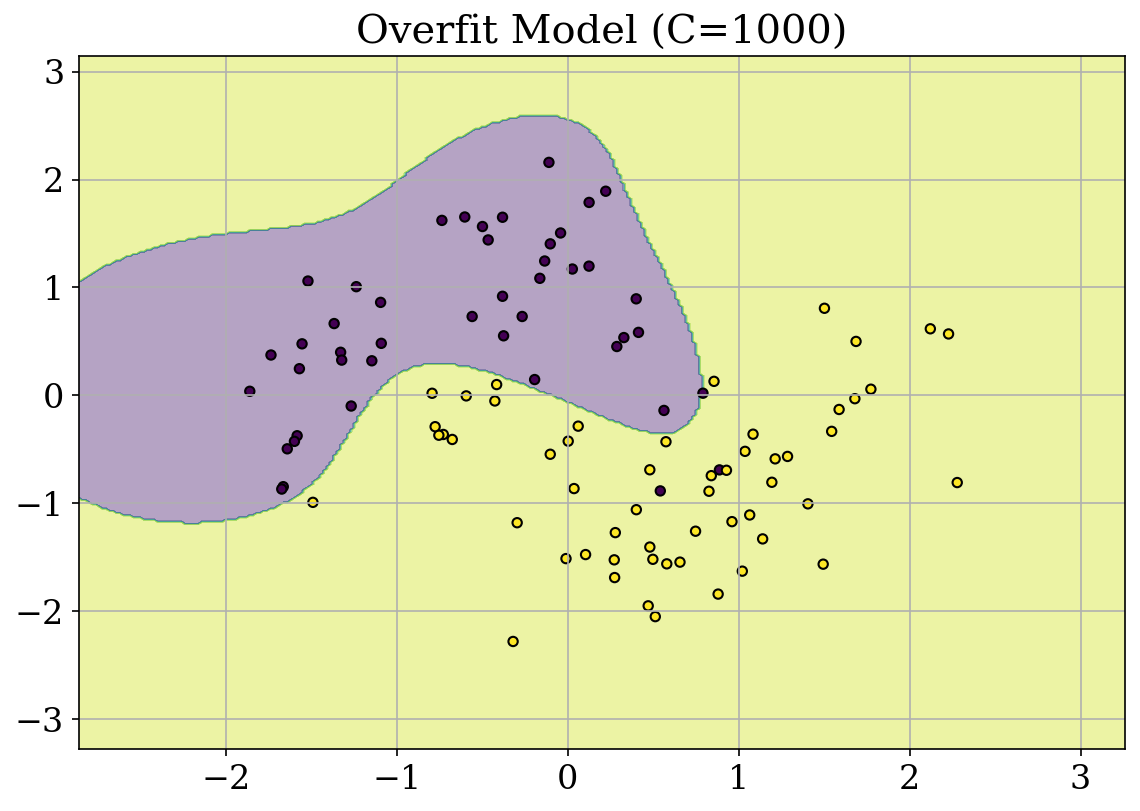

In [13]:
# Task 4: Overfitting
X_small, _, y_small, _ = train_test_split(X, y, train_size=100, random_state=42)
overfit_model = SVC(kernel='rbf', C=1000, gamma='scale')
overfit_model.fit(X_small, y_small)
plot_decision_boundary(X_small, y_small, overfit_model, 'Overfit Model (C=1000)')
print(f"Overfit model - Train: {overfit_model.score(X_small, y_small):.2f}, Test: {overfit_model.score(X_test, y_test):.2f}")
